Episode 0, Average Reward: 9.3
Episode 100, Average Reward: 79.74
Episode 200, Average Reward: 96.1
Episode 300, Average Reward: 98.89
Episode 400, Average Reward: 99.04
Episode 500, Average Reward: 105.06
Episode 600, Average Reward: 171.7
Episode 700, Average Reward: 86.4
Episode 800, Average Reward: 157.05
Episode 900, Average Reward: 90.9
Episode 1000, Average Reward: 296.47
Target average reward of 195 reached at episode 1000.
Episode 1100, Average Reward: 130.67
Episode 1200, Average Reward: 187.78
Episode 1300, Average Reward: 58.71
Episode 1400, Average Reward: 147.28
Episode 1500, Average Reward: 116.77
Episode 1600, Average Reward: 216.93
Episode 1700, Average Reward: 134.97
Episode 1800, Average Reward: 115.25
Episode 1900, Average Reward: 58.21


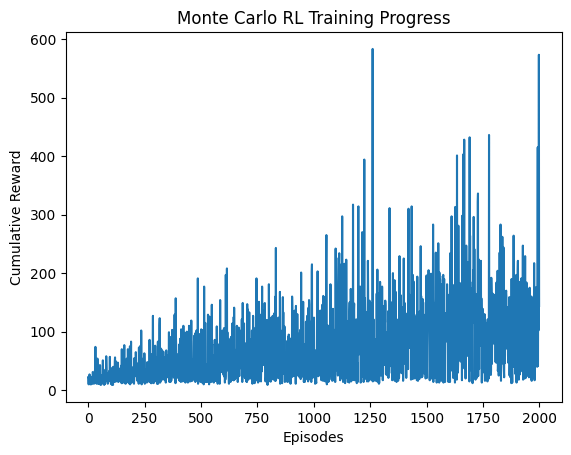

Sample State: (5, 5, 5, 5), Chosen Action: 1
Average reward over 100 episodes: 138.33


/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:75: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/monitoring/video_recorder.py:59: UserWarning: WARN: Disabling video recorder because environment <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>> was not initialized with any compatible video mode between `rgb_array` and `rgb_array_list`
  logger.warn(
/usr/local/lib/python3.11/dist-packages/gym/envs/classic_control/cartpole.py:211: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(


In [25]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle
from collections import defaultdict
from gym.wrappers import RecordVideo

# Create the CartPole environment
env = gym.make("CartPole-v1")

# Define bins for discretization (since state values are continuous)
state_bins = [
    np.linspace(-4.8, 4.8, 10),    # Cart Position
    np.linspace(-4, 4, 10),        # Cart Velocity
    np.linspace(-0.418, 0.418, 10),# Pole Angle
    np.linspace(-4, 4, 10)         # Pole Velocity
]

def discretize_state(state):
    """Convert continuous state into a discrete tuple"""
    return tuple(np.digitize(s, bins) for s, bins in zip(state, state_bins))

def default_q_values():
    return np.zeros(env.action_space.n)

def epsilon_greedy_policy(Q, state, epsilon):
    """Choose an action using an epsilon-greedy policy"""
    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample()  # Explore
    else:
        return np.argmax(Q[state])  # Exploit

def generate_episode(env, Q, epsilon):
    """Generate an episode following the given policy"""
    episode = []
    state = discretize_state(env.reset()[0])
    done = False

    while not done:
        action = epsilon_greedy_policy(Q, state, epsilon)
        next_state, reward, done, _, _ = env.step(action)
        episode.append((state, action, reward))
        state = discretize_state(next_state)

    return episode

def evaluate_agent(env, Q, num_episodes=100):
    """Evaluate the agent's performance over a number of episodes"""
    total_rewards = []

    for _ in range(num_episodes):
        state = discretize_state(env.reset()[0])
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(Q[state])
            next_state, reward, done, _, _ = env.step(action)
            total_reward += reward
            state = discretize_state(next_state)

        total_rewards.append(total_reward)

    return np.mean(total_rewards)

def monte_carlo_control(env, gamma=0.99, alpha=0.1, epsilon=1.0, epsilon_decay=0.999, target_avg_reward=195, eval_interval=100, max_episodes=2000):
    """Monte Carlo Control algorithm to learn optimal Q-values"""
    Q = defaultdict(default_q_values)
    rewards_per_episode = []
    episode_num = 0
    target_reached = False

    while episode_num < max_episodes:
        episode = generate_episode(env, Q, epsilon)
        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            if (state, action) not in visited:
                # Incremental Q-value update instead of averaging all returns
                Q[state][action] += alpha * (G - Q[state][action])
                visited.add((state, action))

        rewards_per_episode.append(sum([x[2] for x in episode]))

        # Decay epsilon over time
        epsilon = max(0.01, epsilon * epsilon_decay)

        # Evaluate the agent periodically
        if episode_num % eval_interval == 0:
            avg_reward = evaluate_agent(env, Q)
            print(f"Episode {episode_num}, Average Reward: {avg_reward}")

            if not target_reached and avg_reward >= target_avg_reward:
                print(f"Target average reward of {target_avg_reward} reached at episode {episode_num}.")
                target_reached = True

        episode_num += 1

    return Q, rewards_per_episode

# Train the agent
Q, rewards_per_episode = monte_carlo_control(env, max_episodes=2000)

# Plot cumulative rewards
plt.plot(np.arange(len(rewards_per_episode)), rewards_per_episode)
plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Monte Carlo RL Training Progress")
plt.savefig("training_progress.png")  # Save the plot as an image
plt.show()

# Task 1: Sample state and chosen action
sample_state = discretize_state(env.reset()[0])
sample_action = epsilon_greedy_policy(Q, sample_state, epsilon=0.1)
print(f"Sample State: {sample_state}, Chosen Action: {sample_action}")

# Task 2: Run agent for 100 episodes and plot average rewards
num_test_episodes = 100
total_rewards = []

for _ in range(num_test_episodes):
    state = discretize_state(env.reset()[0])
    done = False
    total_reward = 0

    while not done:
        action = np.argmax(Q[state])
        next_state, reward, done, _, _ = env.step(action)
        total_reward += reward
        state = discretize_state(next_state)

    total_rewards.append(total_reward)

average_reward = np.mean(total_rewards)
print(f"Average reward over {num_test_episodes} episodes: {average_reward}")

# Task 3: Render one episode and record a video
video_env = RecordVideo(env, "video", episode_trigger=lambda x: True)  # Record video for one episode
state = discretize_state(video_env.reset()[0])
done = False

while not done:
    action = np.argmax(Q[state])
    next_state, reward, done, _, _ = video_env.step(action)
    state = discretize_state(next_state)

video_env.close()  # Close the video environment

# Save Q-table
for state in Q:
    Q[state] = list(Q[state])  # Ensure it's a list before pickling

with open("monte_carlo_qtable.pkl", "wb") as f:
    pickle.dump(Q, f)

In [26]:
import gym
from gym.wrappers import RecordVideo
import numpy as np
from collections import defaultdict

# Create the CartPole environment with video recording
video_env = RecordVideo(gym.make("CartPole-v1", render_mode="rgb_array"), "video", episode_trigger=lambda x: True)

# Load the Q-table (assuming it has been trained and saved)
with open("monte_carlo_qtable.pkl", "rb") as f:
    Q = pickle.load(f)

# Task 3: Render one episode and record a video
state = discretize_state(video_env.reset()[0])
done = False

while not done:
    action = np.argmax(Q[state])
    next_state, reward, done, _, _ = video_env.step(action)
    state = discretize_state(next_state)

video_env.close()  # Close the video environment to save the video

Moviepy - Building video /content/video/rl-video-episode-0.mp4.
Moviepy - Writing video /content/video/rl-video-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /content/video/rl-video-episode-0.mp4
